# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("✅ Dataset created successfully!")

# Display first few rows
df.head(10)

✅ Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card
5,6,21,Student,East,2023-01-06,Home,4,141.41,565.64,5,Credit Card
6,7,83,Student,East,2023-01-07,Books,2,127.43,254.86,0,Debit Card
7,8,87,Senior,South,2023-01-08,Sports,1,130.31,130.31,20,Debit Card
8,9,75,Professional,West,2023-01-09,Clothing,2,53.49,106.98,0,Credit Card
9,10,75,Professional,North,2023-01-10,Electronics,2,54.20,108.40,0,PayPal


## Data Exploration

Let's start by understanding our dataset:

In [2]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


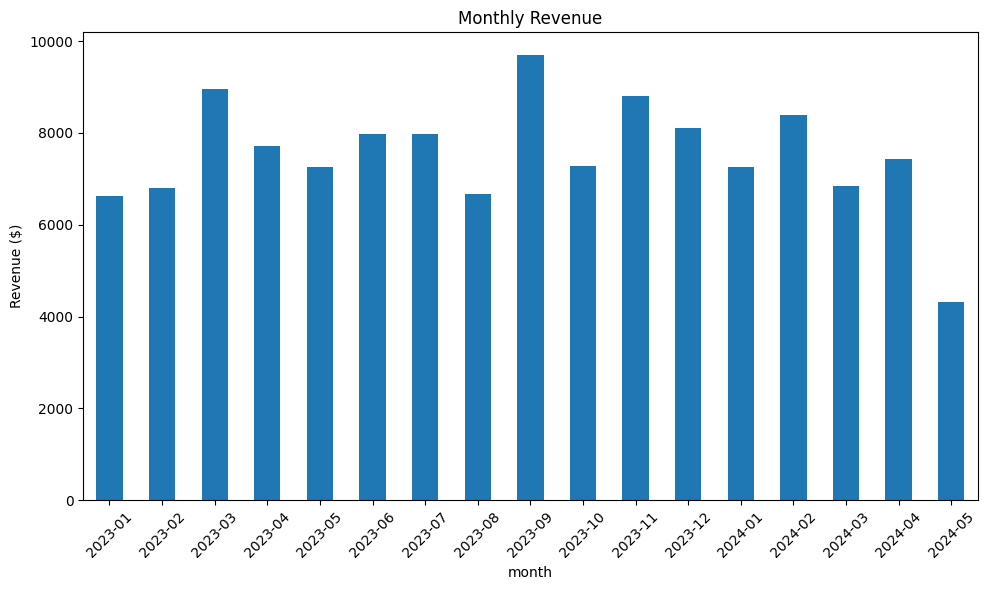

In [3]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

Q1 revenue was $22,493, average about $7,498 per month. January came in at $7268.59, February is the peak at $8,388, up about 15 percent from January. March came in at $6,836, down about 18 percent from February and about 6 percent below January.

February pops up and going into March it gives some of it back. I would check March for lighter promos/discounts or a campaign gap, then repeat what worked in February.

Last Quarter Report:
month
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
Freq: M, Name: revenue, dtype: float64


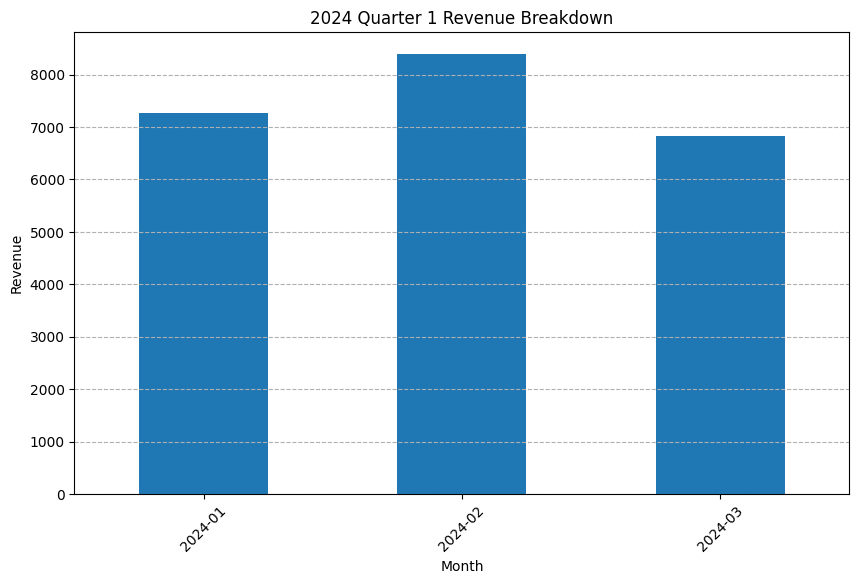

In [4]:
# Your code here
data['quarter'] = data['order_date'].dt.quarter
data['year'] = data['order_date'].dt.year

current_year = data['year'].max()
current_quarter = data[data['year'] == current_year]['quarter'].max()

#Makes sure the there is previous year data
if (current_quarter - 1 == 0) and (data['year'].isin([current_year-1]).any()):
        last_quarter = 4
        quarter_year = current_year -1
else:
    last_quarter = current_quarter - 1
    quarter_year = current_year

last_quarter_df = data[(data['year'] == quarter_year) & (data['quarter'] == last_quarter)]


last_quarter_report = last_quarter_df.groupby(['month'])['revenue'].sum()
print(f'Last Quarter Report:\n{last_quarter_report}')
last_quarter_report.plot(kind='bar', figsize = (10,6),title= f'{quarter_year} Quarter {last_quarter} Revenue Breakdown')
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation = 45)
plt.grid(axis='y', linestyle='--')
plt.show()





### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

The top five customers are carrying a big chunk of revenue and it's mostly Seniors and Professionals. I would lock these in with a simple retention plan like having early access on high value items and a check-in offer, then I would look for two to three lookalikes in those customer segments to grow the list further. Moving foward we should be tracking their monthly spend and make sure we never stock out on what they actually buy.

In [15]:
# Your code here
top5 = data.groupby('customer_id').agg({'revenue': 'sum','customer_segment': 'first'}).sort_values(by= 'revenue',ascending=False).reset_index()
top5.head()





,customer_id,revenue,customer_segment
0,62,4448.39,Senior
1,24,3369.44,Professional
2,90,2976.78,Senior
3,92,2838.74,Professional
4,97,2835.62,Professional


### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

Seniors have the highest average spend at about $262, Professionals are around $256, and Students are about $254. The gap is small, so I would keep the core offer the same  to all maybe bumping up promos and advertising to studesnts to pick the up from the bottom.

In [16]:
# Your code here
segment_avg = data.groupby('customer_segment')['revenue'].mean().sort_values(ascending=False).reset_index()
segment_avg

,customer_segment,revenue
0,Senior,262.133925
1,Professional,255.652674
2,Student,253.812087


### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

South and North lead on total revenue which the south being marginally higher, so that is where we keep pushing. West has the largest average order size but still trails on the revenue which points to lower priced items bought or heavier discounting. I would keep the premium inventory tight in South and North and test price mix in the west to turn those bigger carts into higher revenue.

In [7]:
# Your code here
top_region = data.groupby("region")["revenue"].sum().sort_values(ascending=False).reset_index()
top_region_avg = data.groupby("region")["quantity"].mean().sort_values(ascending=False).reset_index()
print(f"Highest Region Revenue:\n{top_region}\nHighest Region Average Order Size:\n{top_region_avg}")

Highest Region Revenue:
  region   revenue
0  South  34839.45
1  North  34351.69
2   East  31221.80
3   West  27727.73
Highest Region Average Order Size:
  region  quantity
0   West  2.627273
1   East  2.469231
2  South  2.440945
3  North  2.360902


### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

Home products lead on both revenue and units sold so we should keep it stocked. Electronics ranks high on revenue with fewer unit which says higher ticket items sre selling so we shoulf lean into premium product promotion and warranties. Books are light on both so we can treat it as fill in inventory or pair it as an add on in bundles with the top sellers.

Products Sorted by Revenue
  product_category   revenue
0             Home  29871.47
1      Electronics  25498.31
2         Clothing  24804.57
3            Books  24046.06
4           Sports  23920.26 


Products Sorted by Quantity
  product_category  quantity
0             Home       269
1         Clothing       253
2           Sports       246
3      Electronics       239
4            Books       227


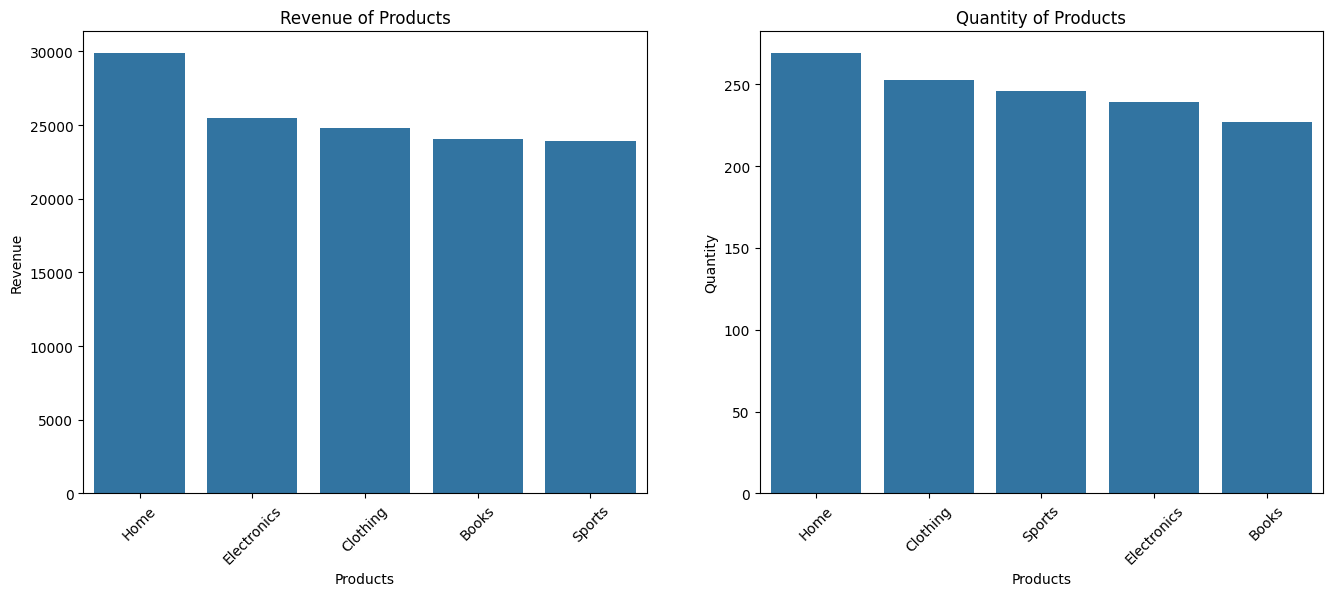

In [8]:
# Your code here
p_rev = data.groupby('product_category')['revenue'].sum().sort_values(ascending=False).reset_index()
p_quant = data.groupby('product_category')['quantity'].sum().sort_values(ascending=False).reset_index()
print("Products Sorted by Revenue")
print(p_rev,"\n\n")
print("Products Sorted by Quantity")
print(p_quant)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.barplot(data=p_rev, x = "product_category", y = "revenue")
plt.title("Revenue of Products")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)

plt.subplot(1,2,2)
sns.barplot(data=p_quant, x = "product_category", y = "quantity")
plt.title("Quantity of Products")
plt.xlabel("Products")
plt.ylabel("Quantity")
plt.xticks(rotation = 45)
plt.show()

### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

Discounted orders bring in less revenue per order. Net average revenue is about $222 vs $248 for non discounted items so we’re giving up money even though quantity per order is a touch higher. There are more discounted orders overall but total net is still lower than the non discounted side. We should use discounts only when we need to clear old stock.

In [9]:
# Your code here
data['discounted'] = data['discount_applied'] > 0
data['net_revenue'] = data['revenue'] * (1 - (data['discount_applied'].astype(float)/100.0))

data.groupby('discounted').agg(net_sum=('net_revenue','sum'), net_mean=('net_revenue', 'mean'), avg_quantity=('quantity', 'mean'), unit_price=('unit_price', 'mean'), order_amount=('order_id', 'count')).reset_index()


,discounted,net_sum,net_mean,avg_quantity,unit_price,order_amount
0,False,60336.0100,248.296337,2.436214,101.364733,243
1,True,56935.1155,221.537414,2.498054,105.556576,257


### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

The payment mix is pretty even but credit a little ahead on usage. Debit cards shows the highest average and median revenue with lower usage so it’s worth looking in to different methods to increase debit usage something like a “Recommended” next to debit or list debit first in the payment options but keep others visible. Gift card sits in the middle, PayPal is lowest.



  payment_method  amount_used  revenue_mean  revenue_median
0    Credit Card          137    257.444234         186.630
1      Gift Card          124    254.362500         215.750
2     Debit Card          123    275.980650         234.160
3         PayPal          116    236.071034         164.945


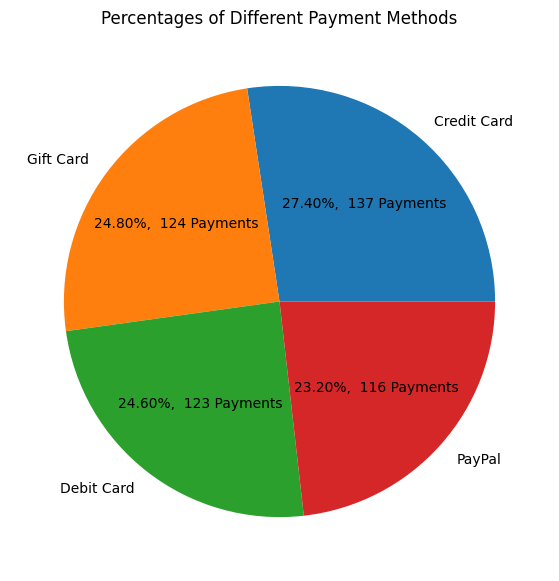

In [10]:
# Your code here

print(data.groupby('payment_method').agg( amount_used=("order_id", "count"), revenue_mean=("revenue", "mean"), revenue_median=('revenue',"median")).sort_values(by="amount_used", ascending=False).reset_index())
pay_counts = data['payment_method'].value_counts()
plt.figure(figsize=(14,7))
pay_counts.plot(kind='pie', autopct = lambda p:f'{p:.2f}%, {p*pay_counts.sum()/100: .0f} Payments')
plt.title("Percentages of Different Payment Methods")
plt.ylabel("")
plt.show()



### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

Weekdays are higher than the the weekends but not by much theres not a significant spike in either direction for any of the days. Wednesdays and Tuesdays are the highest averges and overall revenue sums, so it might be worth it to considering pushing promos for the middle of the week.

  day_of_week     r_sum  buy_counts      r_mean
6   Wednesday  18908.21          71  266.312817
5     Tuesday  18968.41          72  263.450139
2    Saturday  18660.35          71  262.821831
0      Friday  18522.40          71  260.878873
4    Thursday  17846.36          71  251.357183
1      Monday  17704.70          72  245.898611
3      Sunday  17530.24          72  243.475556


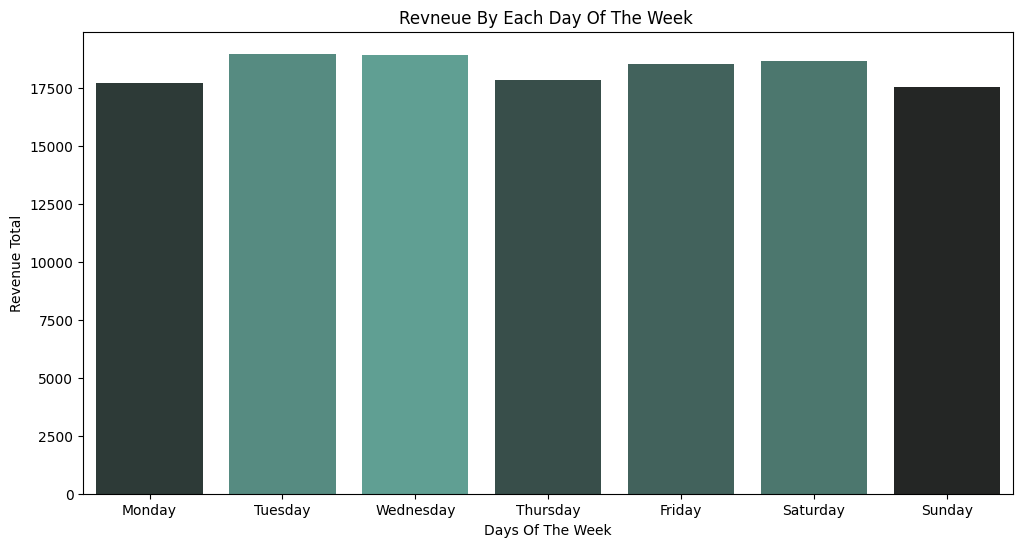

In [17]:
# Your code here
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = data.groupby('day_of_week').agg(r_sum=('revenue', 'sum'),buy_counts=('order_id', 'count'), r_mean=('revenue', 'mean') ).reset_index().sort_values(by='r_mean', ascending=False)
print(dow)

plt.figure(figsize=(12,6))
sns.barplot(data=dow,x= 'day_of_week', y='r_sum', palette='dark:#5A9_r', hue='day_of_week', legend=False, order=day_order)
plt.title("Revneue By Each Day Of The Week ")
plt.xlabel("Days Of The Week")
plt.ylabel("Revenue Total")

plt.show()


### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

With the 20 percent margin the profit mirrors revenue charts. The south is the most profitable, north is next, then east, with west last. This shows where the money are concentrated right now.

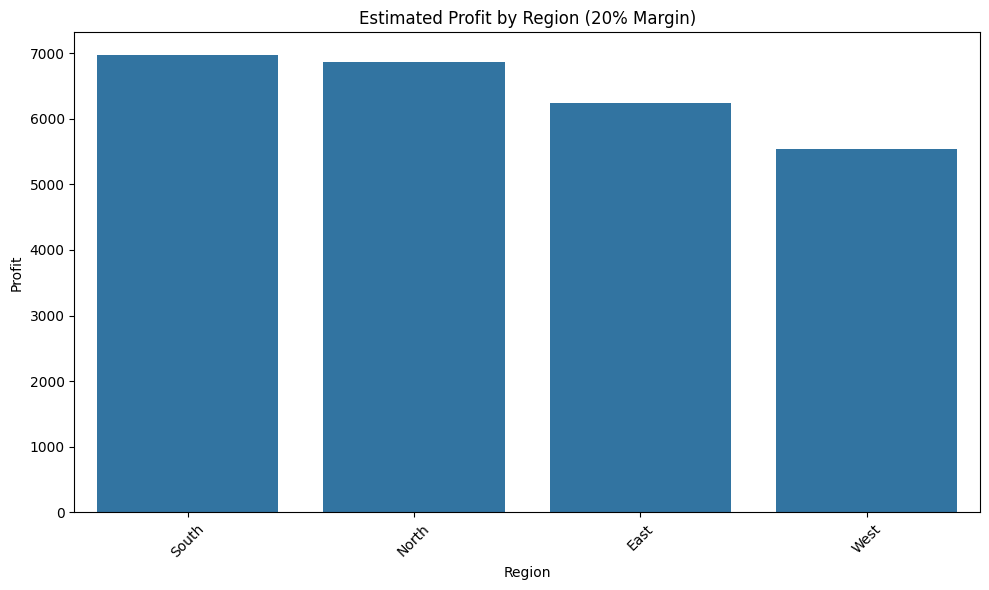

In [12]:
# Your code here
data['profit'] = data['revenue'] * 0.2
region_profit = data.groupby('region')['profit'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=region_profit, x="region", y="profit")
plt.title("Estimated Profit by Region (20% Margin)")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

The South and North are already bringing in the most revenue with fewer items, so that’s where we should push harder and keep high value items in stock, we could add a couple bundle offers and try to bump up the quantity without leaning on discounts. Discounts don’t seem worth it overall and unless it’s stale inventory we should only be using them just to clear space. Payment methods are pretty even, but debit has a higher average order this is worth a small checkout nudge and see if it sticks. Weekday vs weekend looks flat, and with a 20% margin, profit also says double down on South/North.

---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.